In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [62]:
df = pd.read_csv("StudentPerformance.csv")


In [65]:
df.shape



(29, 6)

In [67]:
df.describe

<bound method NDFrame.describe of     math score  reading score  writing score  placement score  club join year  \
0           69             91             74               96            2021   
1           61             80             75               89            2020   
2           62             90             70               92            2020   
3           77             84             80               87            2021   
4           75             83             77               94            2019   
5           80             84             74               92            2021   
6           72             78             61               87            2020   
7           67             79             60               95            2018   
8           60             80             67               94            2021   
9           61             80             68               80            2018   
10          65             81             67               94            20

In [69]:
df.isnull()

,math score,reading score,writing score,placement score,club join year,placement offer count
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [71]:
series = pd.isnull(df["math score"])
df[series]

,math score,reading score,writing score,placement score,club join year,placement offer count


CHECKING THE MISSING VALUES USING notnull()

In [74]:
import pandas as pd
import numpy as np

In [76]:
df = pd.read_csv("/Users/pradnya/Documents/StudentPerformance.csv")

In [78]:
df

,math score,reading score,writing score,placement score,club join year,placement offer count,gender
0,70.0,80.0,76.0,90.0,2021,3,NaN
1,75.0,86.0,80.0,NaN,2020,3,NaN
2,62.0,76.0,NaN,100.0,2021,3,NaN
3,60.0,NaN,65.0,77.0,2021,3,NaN
4,67.0,86.0,61.0,95.0,2020,3,NaN
5,NaN,82.0,80.0,85.0,2020,3,NaN
6,74.0,81.0,71.0,76.0,2020,3,NaN
7,62.0,82.0,67.0,83.0,2020,3,NaN
8,67.0,93.0,76.0,93.0,2018,3,NaN
9,60.0,90.0,78.0,83.0,2021,3,NaN


In [80]:
df.notnull()

,math score,reading score,writing score,placement score,club join year,placement offer count,gender
0,True,True,True,True,True,True,False
1,True,True,True,False,True,True,False
2,True,True,False,True,True,True,False
3,True,False,True,True,True,True,False
4,True,True,True,True,True,True,False
5,False,True,True,True,True,True,False
6,True,True,True,True,True,True,False
7,True,True,True,True,True,True,False
8,True,True,True,True,True,True,False
9,True,True,True,True,True,True,False


In [82]:
series1 = pd.notnull(df["math score"])
df[series1]

,math score,reading score,writing score,placement score,club join year,placement offer count,gender
0,70.0,80.0,76.0,90.0,2021,3,NaN
1,75.0,86.0,80.0,NaN,2020,3,NaN
2,62.0,76.0,NaN,100.0,2021,3,NaN
3,60.0,NaN,65.0,77.0,2021,3,NaN
4,67.0,86.0,61.0,95.0,2020,3,NaN
6,74.0,81.0,71.0,76.0,2020,3,NaN
7,62.0,82.0,67.0,83.0,2020,3,NaN
8,67.0,93.0,76.0,93.0,2018,3,NaN
9,60.0,90.0,78.0,83.0,2021,3,NaN
10,71.0,89.0,70.0,85.0,2019,3,NaN


In [84]:
numeric_cols = df.select_dtypes(include='number').columns
print("Numeric columns:", numeric_cols.tolist())


Numeric columns: ['math score', 'reading score', 'writing score', 'placement score', 'club join year', 'placement offer count', 'gender']


In [86]:
# Find outliers using IQR method
outliers = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_indices = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outliers[col] = outlier_indices.tolist()
    print(f"{col}: {len(outlier_indices)} outliers")


math score: 0 outliers
reading score: 0 outliers
writing score: 0 outliers
placement score: 0 outliers
club join year: 0 outliers
placement offer count: 0 outliers
gender: 0 outliers


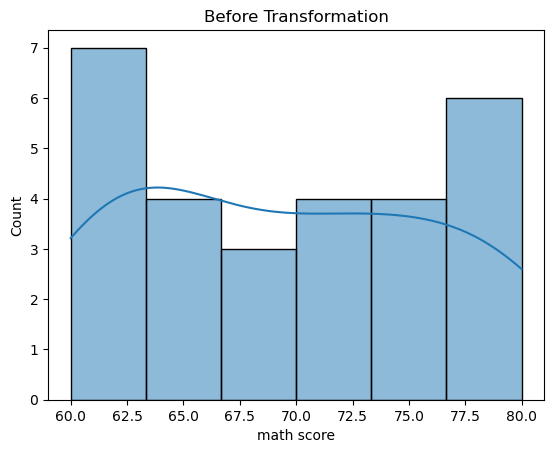

In [88]:


sns.histplot(df['math score'], kde=True)
plt.title('Before Transformation')
plt.show()


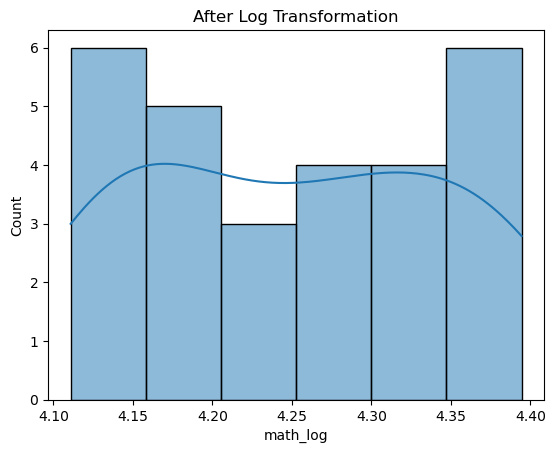

In [91]:
# Adding a small constant to avoid log(0)
df['math_log'] = np.log(df['math score'] + 1)

# Plot transformed distribution
sns.histplot(df['math_log'], kde=True)
plt.title('After Log Transformation')
plt.show()




In [2]:
scaler = MinMaxScaler()
df['math_scaled'] = scaler.fit_transform(df[['math score']])



NameError: name 'MinMaxScaler' is not defined